# Root Locus Design

## ZN Tuning

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [105]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat
from scipy.signal import find_peaks
from IPython.display import clear_output

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## Find Parameters of System response on 10-14

In [106]:
# create interesting transfer function
G = ct.tf(1, np.convolve((1,3),np.convolve((1,1),(1,2))))
if 1: # add some delay
    T_delay = 0.5
    num,den = ct.pade(T_delay, 2)
    G *= ct.tf(num, den)
# step response
[y,t] = cmat.step(G)
A = np.max(y)              # steady-state value (assumes monotone)
dt = t[1] - t[0]
# -------------------------------------------------
# Derivatives (use gradient for stability)
# -------------------------------------------------
dy = np.gradient(y, dt)
ddy = np.gradient(dy, dt)
# -------------------------------------------------
# Inflection point = max slope
# -------------------------------------------------
II = np.argmax(dy)         # robust definition of inflection
t_i = t[II]
y_i = y[II]
R = dy[II]                 # slope at inflection
# -------------------------------------------------
# Tangent-line parameters
# -------------------------------------------------
L = t_i - y_i / R          # delay (x-intercept of tangent)
t_A = t_i + (A - y_i) / R  # time when tangent reaches steady-state
tau = t_A - L              # time constant
t2 = (A-y[II])/R + t[II] # time to get to max resp at rate R

print(f"Steady-state A = {A:.3f}")
print(f"Inflection time ti = {t_i:.3f}")
print(f"Slope R = {R:.3f}")
print(f"Delay L = {L:.3f}")
print(f"Time constant tau = {tau:.3f}")

Steady-state A = 0.166
Inflection time ti = 1.612
Slope R = 0.074
Delay L = 0.931
Time constant tau = 2.242


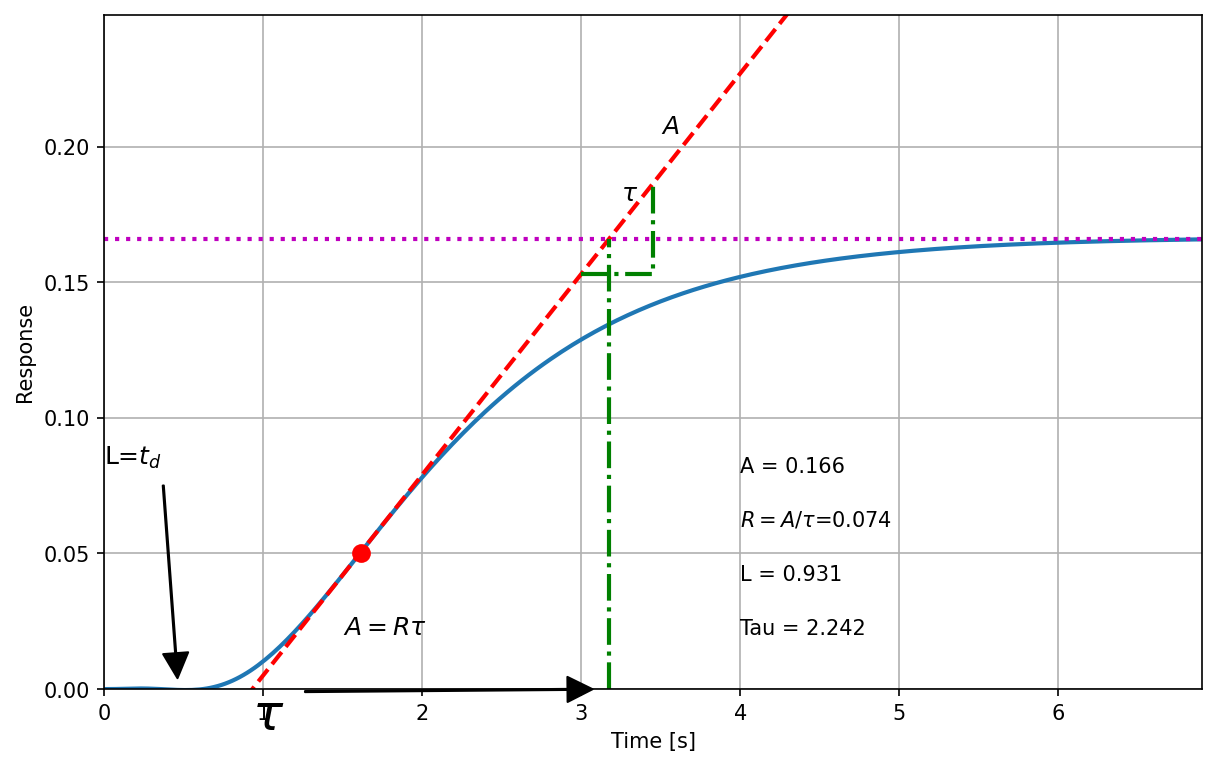

In [107]:
fig, ax = plt.subplots(1, figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,y)
plt.plot(t[II],y[II],'ro',ms=8); # point of inflection
plt.plot([t[0], t[-1]],[np.max(y), np.max(y)],'m:');
plt.plot(t,R*(t-t[II])+y[II],'r--');
plt.plot([t2, t2],[0., np.max(y)],'g-.');

x = 3 # location to draw tau and A
mag = 5
plt.plot([x, x+tau/mag, x+tau/mag],[(x-L)*R, (x-L)*R, (x-L)*R+A/mag],'g-.');
plt.text(3.25,.18,r'$\tau$',fontsize=12)
plt.text(3.5,.205,r'$A$',fontsize=12)

plt.text(4,.08,"A = {:4.3f}".format(A))
plt.text(4,.06,r'$R = A/\tau$={:4.3f}'.format(R))
plt.text(4,.04,"L = {:4.3f}".format(L))
plt.text(4,.02,"Tau = {:4.3f}".format(tau))

ax.set_xlabel('Time [s]')
ax.set_ylabel('Response')
plt.xlim([0, max(t)]);
plt.ylim([0, 1.5*A]);

plt.annotate(r'L=$t_d$', xy=(L/2, 0), xytext=(0, A/2), arrowprops=dict(facecolor='black', shrink=.05, width=0.5),fontsize=12)
plt.annotate(r'$\tau$', xy=(L+tau, 0), xytext=(L, -0.015), arrowprops=dict(facecolor='black', shrink=.05, width=0.5),fontsize=24)
plt.text(1.5,.02,r'$A=R\tau$',fontsize=12)
plt.savefig("./figs/L12_ZN2.pdf", dpi=600)

plt.show()

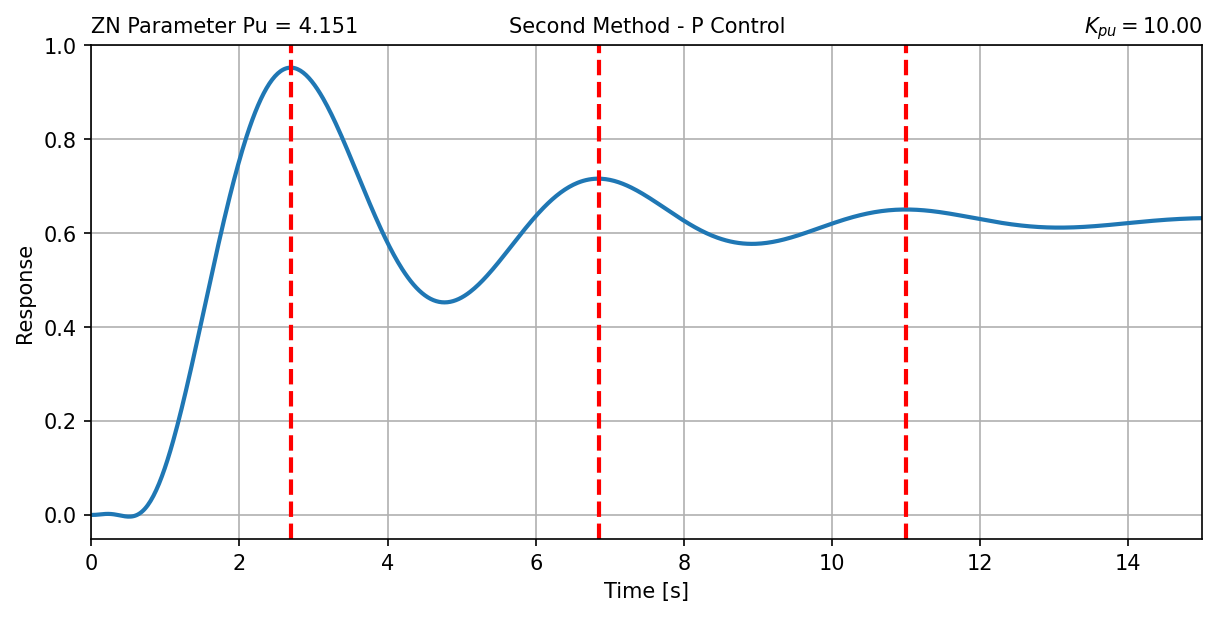

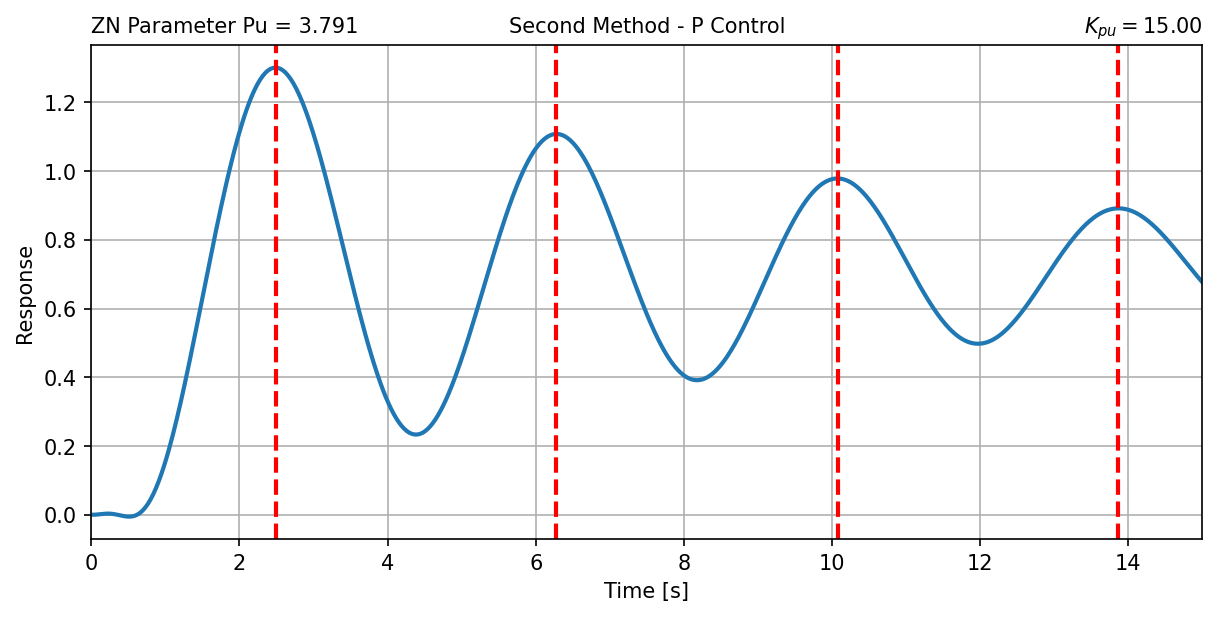

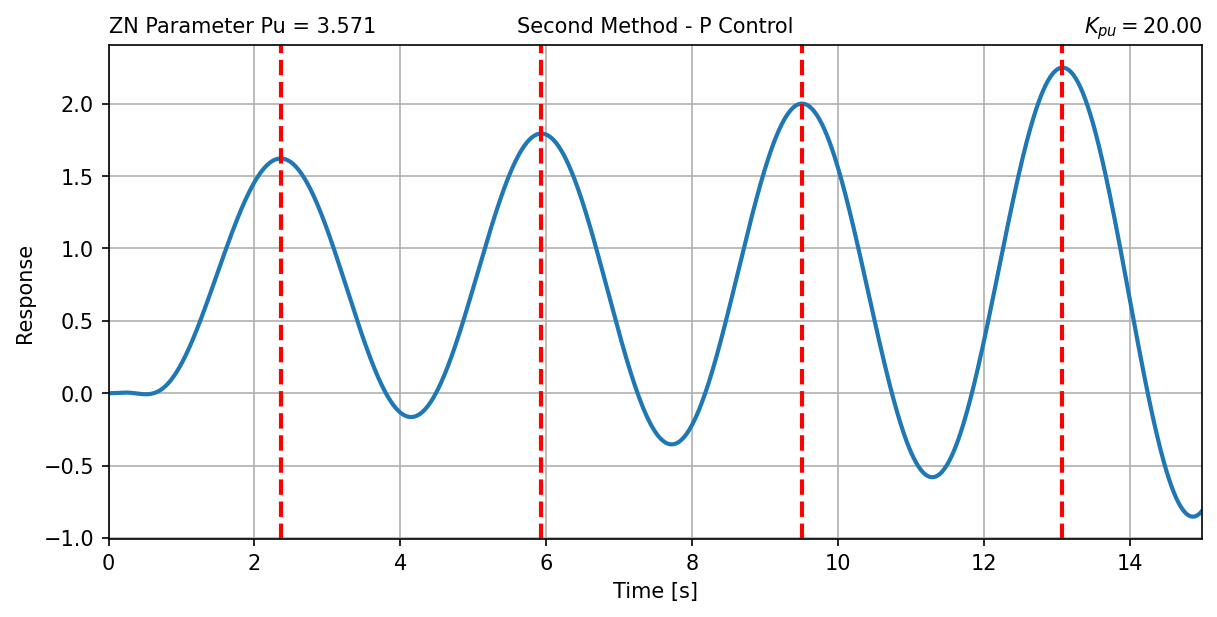

In [108]:
def ZNplot(G, Kpu = 60, ax=ax, ignore_peaks = 1):
    ''' Plot Ziegler-Nichols P-control step response for given Kpu'''
    Gclp = ct.feedback(Kpu*G)
    [yy,tt] = cmat.step(Gclp,15)
    ax.plot(tt,yy)
    
    LOCS,_ = find_peaks(yy)
    if len(LOCS) < (ignore_peaks + 1):
        print("Not enough peaks found, increase Kpu")
        return None
    [ax.axvline(x=tt[LOCS[kk]],color='red',ls='dashed') for kk in range(ignore_peaks,len(LOCS))]
    
    Pu = np.mean(np.diff(tt[LOCS[ignore_peaks:]]));
    ax.set_title("ZN Parameter Pu = {:4.3f}".format(Pu),loc='left')
    
    ax.set_title('Second Method - P Control')
    ax.set_title(r'$K_{{pu}}={:.2f}$'.format(Kpu),loc='right')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Response')
    return Pu

Kpu = 10 # guess
fig, ax = plt.subplots(1, figsize=(8, 4),dpi=150,constrained_layout = True)
Pu = ZNplot(G,Kpu,ax=ax)
plt.savefig("./figs/L12_ZN1a.pdf", dpi=600)

Kpu = 15 # guess
fig, ax = plt.subplots(1, figsize=(8, 4),dpi=150,constrained_layout = True)
Pu = ZNplot(G,Kpu,ax=ax)
plt.savefig("./figs/L12_ZN1b.pdf", dpi=600)

Kpu = 20 # guess
fig, ax = plt.subplots(1, figsize=(8, 4),dpi=150,constrained_layout = True)
Pu = ZNplot(G,Kpu,ax=ax)
plt.savefig("./figs/L12_ZN1.pdf", dpi=600)


## Process Reaction Method

In [109]:
# P
Kp = tau/L
Gcp = cm.pid(Kp = Kp)

# PI
Kp = 0.9*tau/L
Ki = 0.27*tau/L
Gcpi = cm.pid(Kp = Kp, Ki = Ki)

# PID
Kp = 1.2*tau/L
Ki = 0.6*tau/L**2
Kd = 0.6*tau
Gcpid = cm.pid(Kp = Kp, Ki = Ki, Kd = Kd)

In [110]:
Gclp=ct.feedback(Gcp*G,1)
Gclpi=ct.feedback(Gcpi*G,1)
Gclpid=ct.feedback(Gcpid*G,1)
cm.show_tf_latex(Gcpid,r'G_{c_{pid}}',show=True)

<IPython.core.display.Math object>

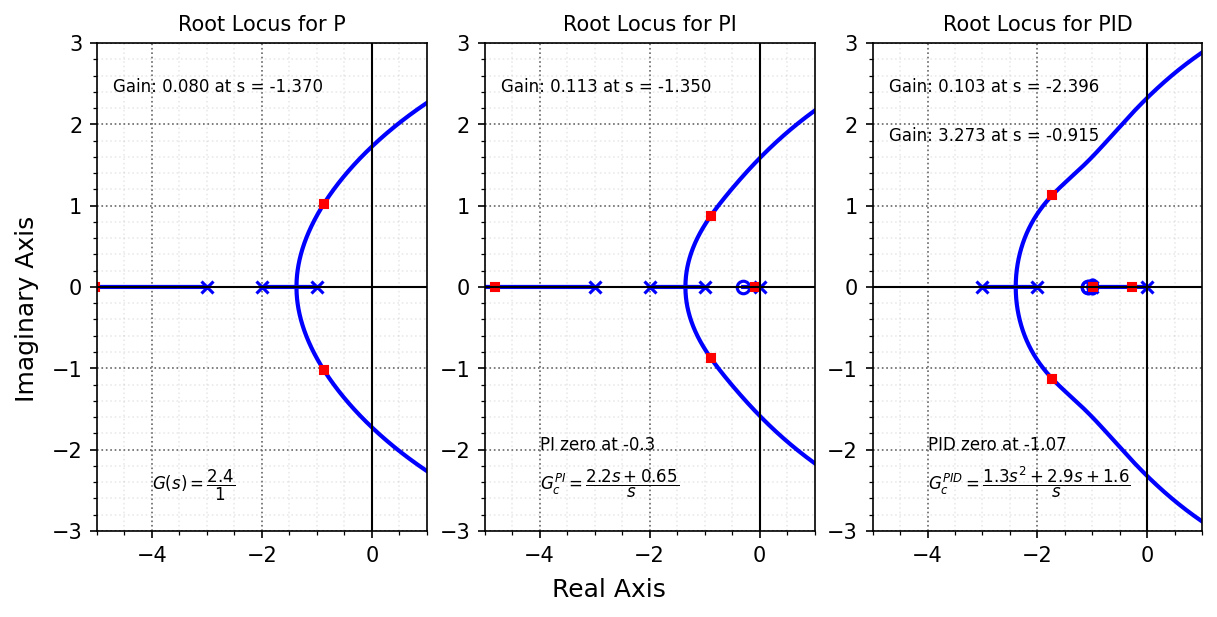

In [111]:
fig, ax = plt.subplots(1,3, figsize=(8, 4),dpi=150,constrained_layout = True)
break_info = [None, None, None]

klist, break_info[0] = cm.Root_Locus_gains(Gcp*G, verbose=True)
ct.rlocus(Gcp*G,gains=klist,ax=ax[0],color='b')
scl = Gclp.poles()
ax[0].plot(scl.real,scl.imag,'rs',ms=4)
ax[0].set_title('Root Locus for P')
ax[0].text(-4,-2.5,cm.show_tf_latex(Gcp),fontsize=8)

klist, break_info[1] = cm.Root_Locus_gains(Gcpi*G, verbose=True)
ct.rlocus(Gcpi*G,gains=klist,ax=ax[1],color='b')
scl = Gclpi.poles()
ax[1].plot(scl.real,scl.imag,'rs',ms=4)
ax[1].text(-4,-2,"PI zero at "+str(round(float(np.real(Gcpi.zeros()[0])),2)),fontsize=8)
ax[1].text(-4,-2.5,cm.show_tf_latex(Gcpi,label='G_c^{PI}'),fontsize=8)
ax[1].set_title('Root Locus for PI')

klist, break_info[2] = cm.Root_Locus_gains(Gcpid*G, verbose=True)
ct.rlocus(Gcpid*G,gains=klist,ax=ax[2],color='b')
scl = Gclpid.poles()
ax[2].plot(scl.real,scl.imag,'rs',ms=4)
ax[2].set_title('Root Locus for PID')
ax[2].text(-4,-2,"PID zero at "+str(round(float(np.real(Gcpid.zeros()[0])),2)),fontsize=8)
ax[2].text(-4,-2.5,cm.show_tf_latex(Gcpid,label='G_c^{PID}'),fontsize=8)
fig.supxlabel("Real Axis")
fig.supylabel("Imaginary Axis")

for ii, axi in enumerate(ax):
    ax[ii].set_xlim([-5, 1])
    ax[ii].set_ylim([-3, 3])
    bm.nicegrid(axi)
    cm.add_break_info(axi, break_info[ii])
    
plt.savefig("./figs/L12_ZN3.pdf", dpi=600)
plt.show()

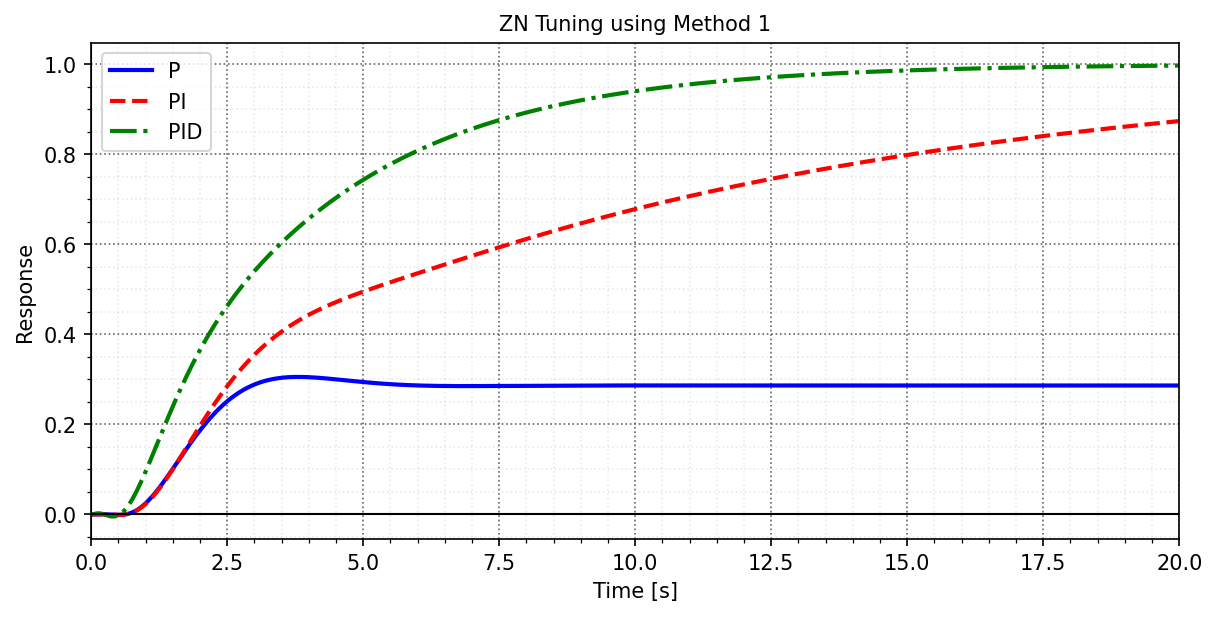

In [112]:
fig, ax = plt.subplots(figsize=(8, 4),dpi=150,constrained_layout = True)
yp,tp = cmat.step(Gclp,20)
ypi,tpi = cmat.step(Gclpi,20)
ypid,tpid = cmat.step(Gclpid,20)

plt.plot(tp,yp,'b-',label='P')
plt.plot(tpi,ypi,'r--',label='PI')
plt.plot(tpid,ypid,'g-.',label='PID')
bm.nicegrid(ax)

plt.legend()
plt.title("ZN First Method")
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.title("ZN Tuning using Method 1")
plt.savefig("./figs/L12_ZN4.pdf", dpi=600)
plt.show()

## Second Method

In [113]:
# Same G as above, but use method 2 to get Kpu and Pu, then apply ZN formulas to get P, PI, PID parameters
# P
Kp = 0.5*Kpu
Gcp = cm.pid(Kp = Kp)
# PI
Kp = 0.45*Kpu
Ki = 0.54*Kpu/Pu
Gcpi = cm.pid(Kp = Kp, Ki = Ki)
# PID
Kp = 0.6*Kpu
Ki = 1.2*Kpu/Pu
Kd = 0.075*Kpu*Pu
Gcpid = cm.pid(Kp = Kp, Ki = Ki , Kd = Kd)

Gclp = ct.feedback(Gcp*G,1)
Gclpi = ct.feedback(Gcpi*G,1)
Gclpid = ct.feedback(Gcpid*G,1)
cm.pretty_row_print(Gcpid.zeros(),msg="PID zeros ")
cm.show_tf_latex(Gcpid,'G_{c}^{PID}',show=True)


PID zeros -1.120, -1.120


<IPython.core.display.Math object>

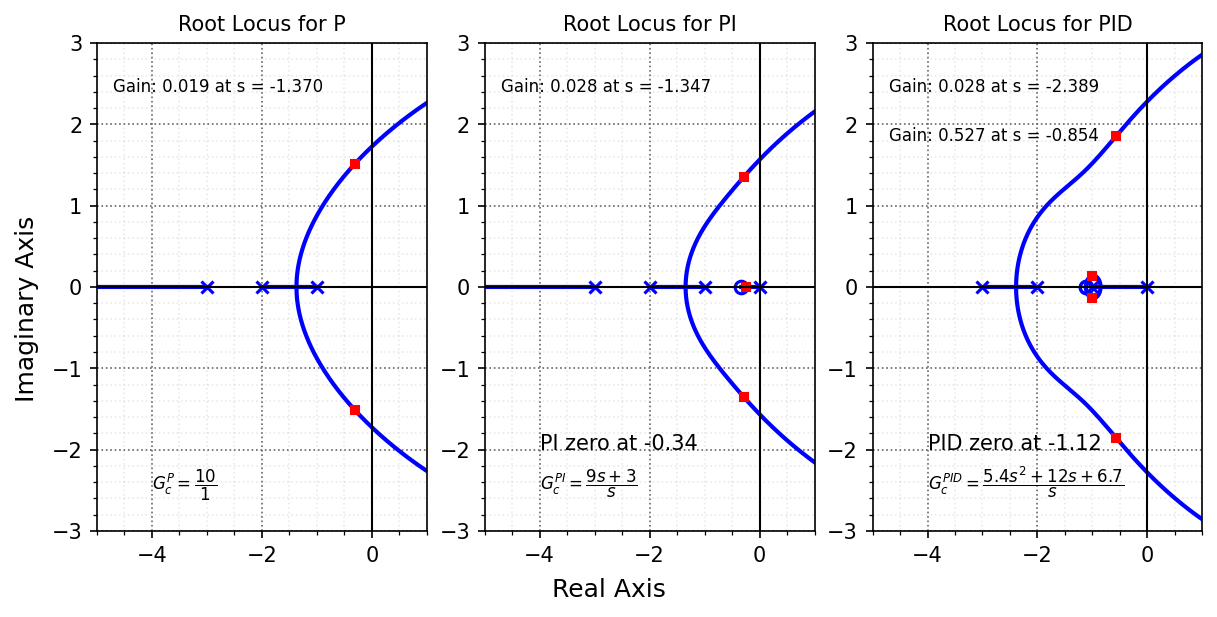

In [114]:
fig, ax = plt.subplots(1,3, figsize=(8, 4),dpi=150,constrained_layout = True)
break_info = [None, None, None]

klist, break_info[0] = cm.Root_Locus_gains(Gcp*G, verbose=True)
ct.rlocus(Gcp*G,gains=klist,ax=ax[0],color='b' )
scl = Gclp.poles()
ax[0].plot(scl.real,scl.imag,'rs',ms=4)
ax[0].set_title('Root Locus for P')
ax[0].text(-4,-2.5,cm.show_tf_latex(Gcp,label='G_c^{P}'),fontsize=8)

klist, break_info[1] = cm.Root_Locus_gains(Gcpi*G, verbose=True)
ct.rlocus(Gcpi*G,gains=klist,ax=ax[1],color='b')
scl = Gclpi.poles()
ax[1].plot(scl.real,scl.imag,'rs',ms=4)
ax[1].set_title('Root Locus for PI')
ax[1].text(-4,-2,"PI zero at "+str(round(float(np.real(Gcpi.zeros()[0])),2)))
ax[1].text(-4,-2.5,cm.show_tf_latex(Gcpi,label='G_c^{PI}'),fontsize=8)

klist, break_info[2] = cm.Root_Locus_gains(Gcpid*G, verbose=True)
ct.rlocus(Gcpid*G,gains=klist,ax=ax[2],color='b' )
scl = Gclpid.poles()
ax[2].plot(scl.real,scl.imag,'rs',ms=4)
ax[2].set_title('Root Locus for PID')
ax[2].text(-4,-2,"PID zero at "+str(round(float(np.real(Gcpid.zeros()[0])),2)))
ax[2].text(-4,-2.5,cm.show_tf_latex(Gcpid,label='G_c^{PID}'),fontsize=8)

fig.supxlabel("Real Axis")
fig.supylabel("Imaginary Axis")

for ii, axi in enumerate(ax):
    ax[ii].set_xlim([-5, 1])
    ax[ii].set_ylim([-3, 3])
    bm.nicegrid(axi)
    cm.add_break_info(axi, break_info[ii])
    
plt.savefig("./figs/L12_ZN5.pdf", dpi=600)
plt.show()

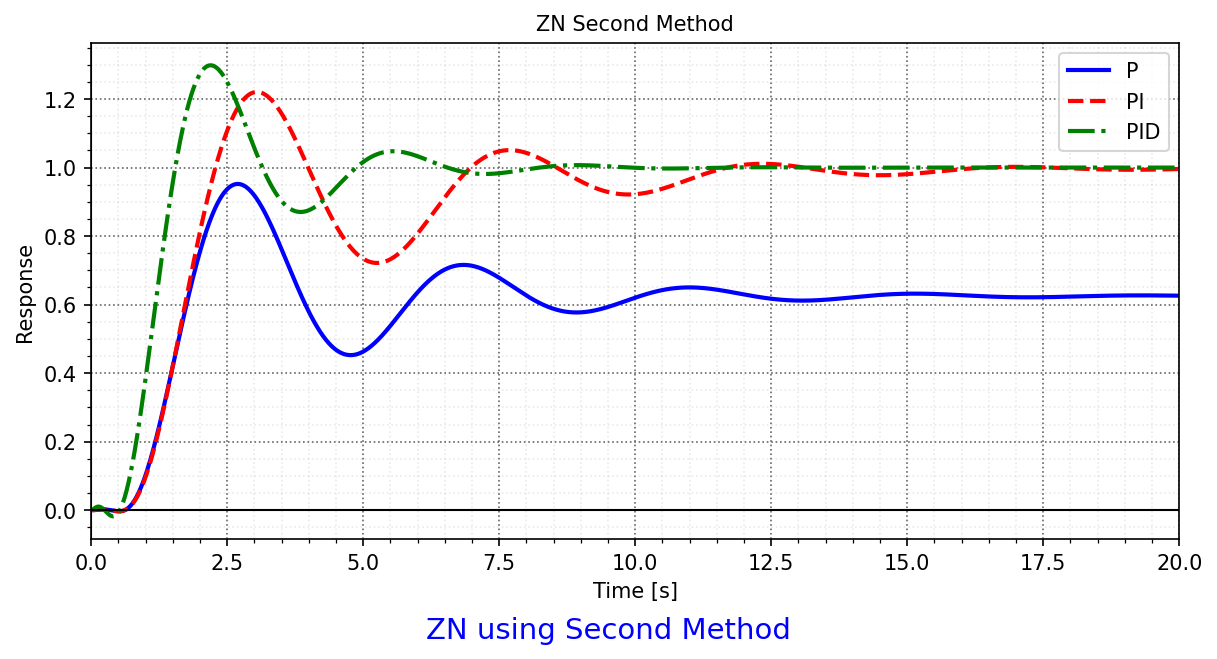

In [115]:
fig, ax = plt.subplots(figsize=(8, 4),dpi=150,constrained_layout = True)
yp,tp = cmat.step(Gclp,20)
ypi,tpi = cmat.step(Gclpi,20)
ypid,tpid = cmat.step(Gclpid,20)

plt.plot(tp,yp,'b-',label='P')
plt.plot(tpi,ypi,'r--',label='PI')
plt.plot(tpid,ypid,'g-.',label='PID')

bm.nicegrid(ax)
plt.title("ZN Second Method")
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.legend()
cm.caption("ZN using Second Method",fig,yloc=-0.05)
plt.savefig("./figs/L12_ZN6.pdf", dpi=600)
plt.show()

## Manual Tuning Approach

In [116]:
def pick_Kp(G, ax=ax, Kp0=20, tt=None, Kstep0=None, max_iter=500, plot_every=None, Tol = 0.04, alpha = 0.1, debug = None):
    '''Not an optimizer - heuristic that searches for the edge of stability by watching peak growth.
    It works surprisingly often, but it is not guaranteed. '''

    Kp = Kp0
    Kp_min = Kp_max = Kp

    if plot_every is None:
        plot_every = max_iter/20

    if tt is None:
        tt = np.linspace(0, 20, 1000)

    if Kstep0 is None:
        Kstep0 = alpha*Kp0

    out_str = None

    for kk in range(max_iter):

        Gc = cm.pid(Kp=Kp)
        Gcl = ct.feedback(Gc*G, 1)
        y, t = cmat.step(Gcl, T=tt)

        if plot_every and kk % plot_every == 0:
            ax.plot(t, y, alpha=0.8, c=colors[int(kk/plot_every) % len(colors)], label=f'Kp={Kp:.2f}')

        peaks, _ = find_peaks(y)
        peak_values = y[peaks]

        if len(peak_values) < 3:
            continue

        peak_diffs = np.diff(peak_values)

        if (np.sum(np.abs(peak_diffs[1:])) < Tol):
            out_str = (f"Converged after iteration {kk}: Kp = {Kp:.3f}")
            ax.plot(t, y, alpha=0.8, c='r', label=f'Kp={Kp:.2f}')
            break

        if debug:
            print(peak_diffs[1:],np.sum(np.abs(peak_diffs[1:])))

        # if not conveged, adjust Kp
        num_positive = np.sum(peak_diffs[1:] > 0)
        num_negative = np.sum(peak_diffs[1:] < 0)
        if debug:
            print(f"Pos {num_positive} Neg {num_negative} Kp = {Kp:.3f}")

        Kstep = Kstep0 / (1 + 0.05*np.sqrt(kk))
        if num_positive > num_negative:
            # Peaks are increasing in size
            Kp -= Kstep
        elif num_positive < num_negative:
            # Peaks are decreasing in size
            Kp += Kstep

        # store min and max Kp tried
        Kp_min = min(Kp, Kp_min)
        Kp_max = max(Kp, Kp_max)

    if out_str is None:
        out_str = "Did not converge after max iterations"

    return Kp, {
        "Kp_crit": Kp,
        "Kp_min": Kp_min,
        "Kp_max": Kp_max,
    }, out_str



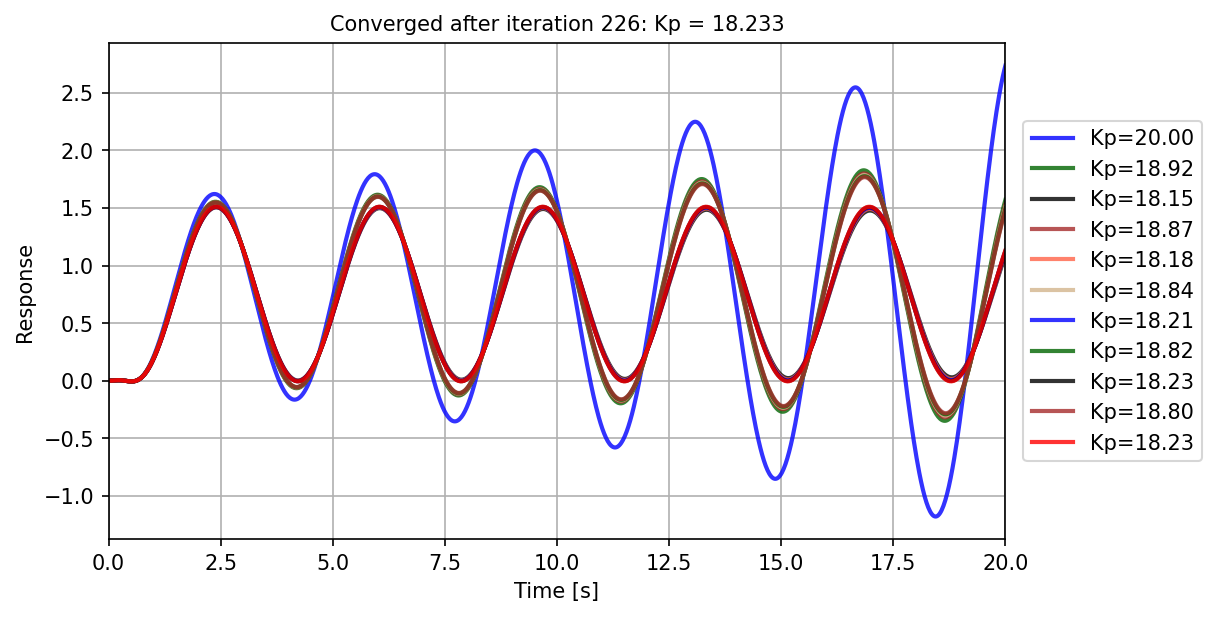

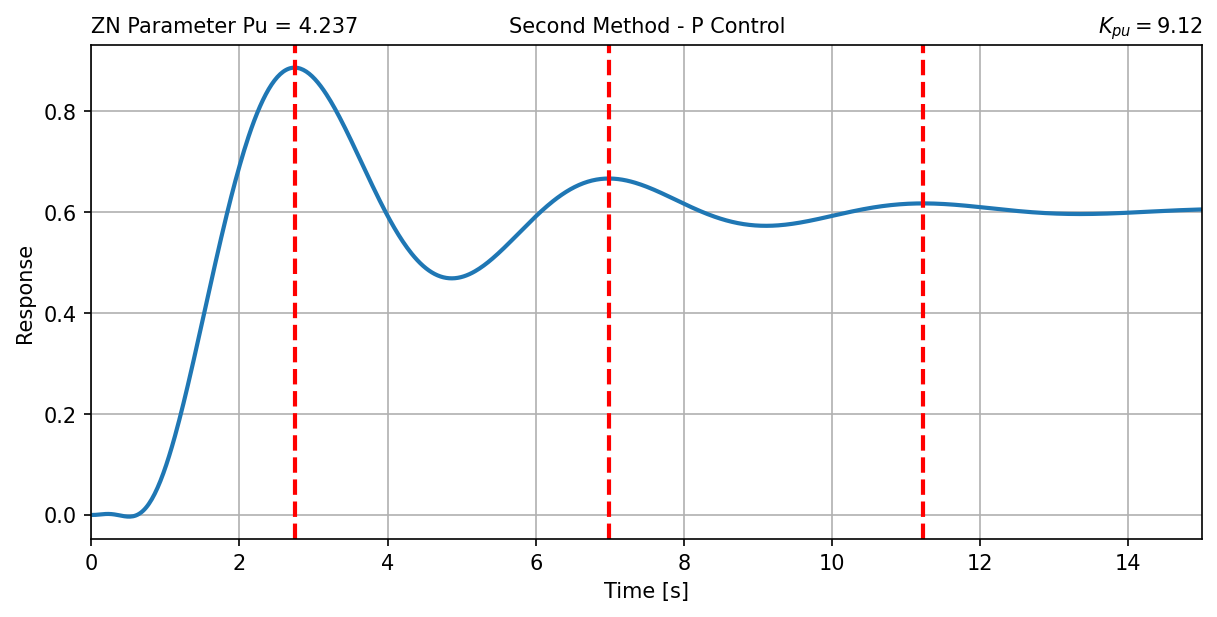

In [117]:
G = ct.tf((0, 1), np.convolve((1,3),np.convolve((1,1),(1,2))))
T_delay = 0.5
num,den = ct.pade(T_delay, 2)
G *= ct.tf(num, den)

fig, ax = plt.subplots(figsize=(8, 4),dpi=150,constrained_layout = True)
Kpu,_,title = pick_Kp(G,ax=ax,max_iter=250,Tol=0.0002,alpha=0.05)
Kp = Kpu/2 # heurstic for stable P control

# add to the plot made during pick_Kp
plt.grid(True)
plt.title(title)
plt.xlabel('Time [s]')
plt.legend(loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0)
plt.ylabel('Response')
plt.savefig("./figs/L10_Manual_PID1.pdf", dpi=600)

fig, ax = plt.subplots(1, figsize=(8, 4),dpi=150,constrained_layout = True)
Pu = ZNplot(G,Kp,ax=ax)
plt.savefig("./figs/L10_Manual_PID2.pdf", dpi=600)
plt.show()

#### Now consider the Ki gain

Ki = 0.365  Ts = 81.416  Mp = 0.000
Ki = 0.820  Ts = 50.670  Mp = 0.000
Ki = 1.276  Ts = 32.006  Mp = 0.024
Ki = 1.732  Ts = 22.865  Mp = 0.075
Ki = 2.188  Ts = 15.983  Mp = 0.128
Ki = 2.644  Ts = 15.203  Mp = 0.181
Ki = 3.100  Ts = 14.983  Mp = 0.235
Ki = 3.555  Ts = 15.083  Mp = 0.290
Ki = 4.011  Ts = 15.403  Mp = 0.344
Ki = 4.467  Ts = 15.763  Mp = 0.399


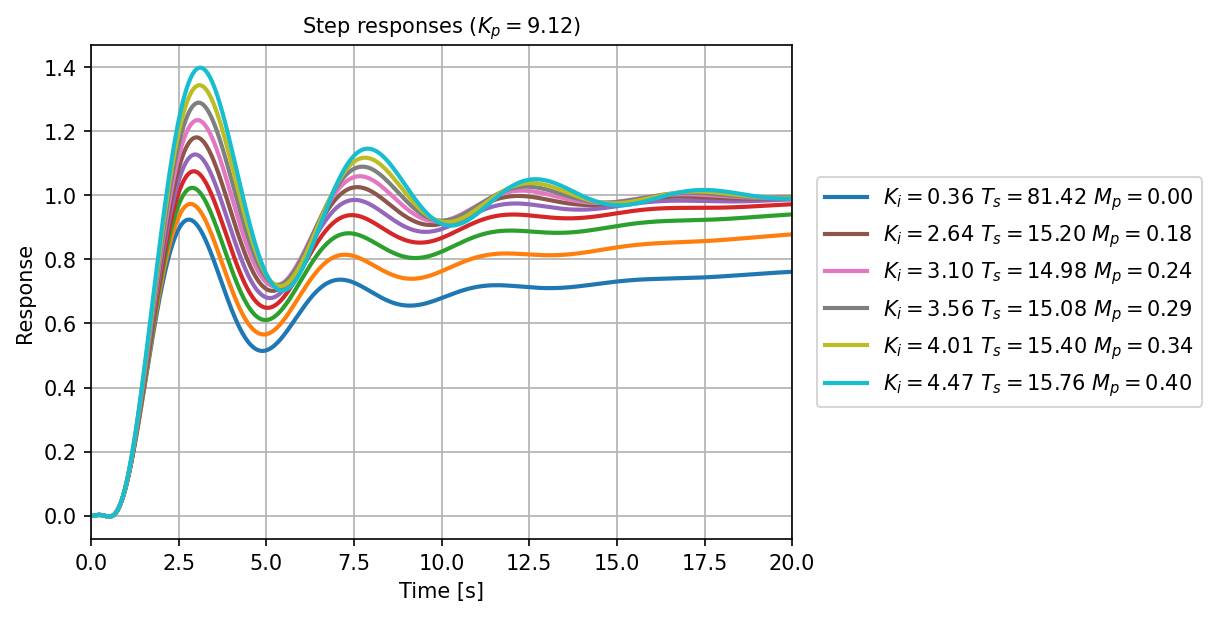

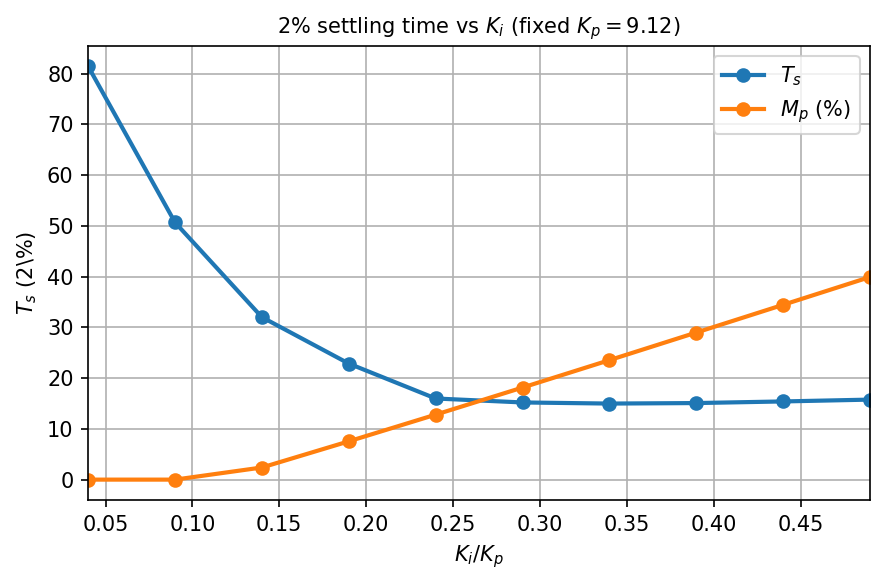

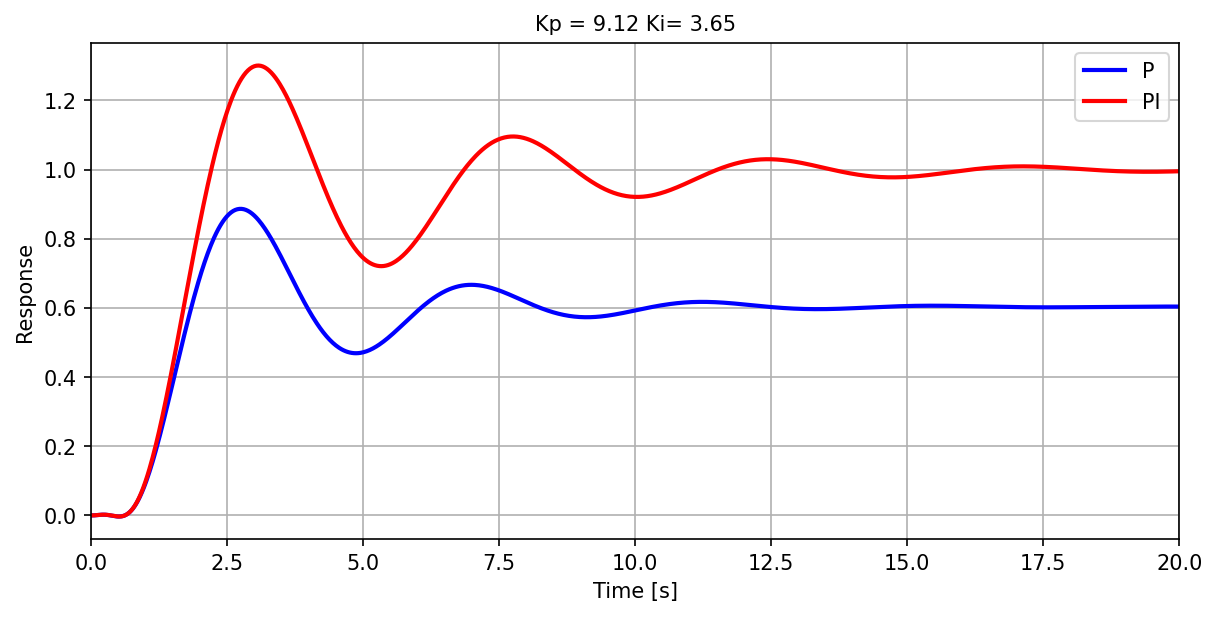

In [118]:
def short_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    if len(labels) > 5:
        idx = [0] + list(range(len(labels) - 5, len(labels)))
    else:
        idx = list(range(len(labels)))
    handles = [handles[i] for i in idx]
    labels  = [labels[i]  for i in idx]
    ax.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

fig, ax = plt.subplots(figsize=(8, 4),dpi=150,constrained_layout = True)

Ki_vals = []
Ts_vals = []
Mp_vals = []
Tf = 100
tt = np.linspace(0, Tf, 1000)
for multiplier in np.arange(.04, .5, 0.05):
    Ki = multiplier * Kp
    Gc = cm.pid(Kp=Kp, Ki=Ki)
    Gcl = ct.feedback(Gc * G, 1)
    y, t = cmat.step(Gcl, max(tt))
    Ts = cm.settling_time(t, y)
    Mp,_ = cm.max_overshoot(t, y)
    print(f"Ki = {Ki:.3f}  Ts = {Ts:.3f}  Mp = {Mp:.3f}")
    Ki_vals.append(Ki)
    Ts_vals.append(Ts)
    Mp_vals.append(100*Mp)
    ax.plot(t, y, label=rf"$K_i={Ki:5.2f}$ $T_s={Ts:5.2f}$ $M_p={Mp:6.2f}$")

ax.set_title(rf"Step responses ($K_p={Kp:.2f}$)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Response")
ax.set_xlim([0, max(t)/5])
short_legend(ax)
plt.savefig("./figs/L10_Manual_PID3.pdf", dpi=600)
plt.show()

plt.figure(figsize=(6, 4), dpi=150)
plt.plot(Ki_vals/Kp, Ts_vals, "o-")
plt.plot(Ki_vals/Kp, Mp_vals, "o-")
plt.xlabel(r"$K_i/K_p$")
plt.ylabel(r"$T_s$ (2\%)")
plt.title(rf"2% settling time vs $K_i$ (fixed $K_p={Kp:.2f}$)")
plt.legend([r"$T_s$", r"$M_p$ (%)"])
plt.grid(True)
plt.show()

Ki = 0.4*Kp
Gcp = cm.pid(Kp = Kp, Ki = 0*Ki)
Gclp = ct.feedback(Gcp*G)
Gcpi = cm.pid(Kp = Kp, Ki = Ki)
Gclpi = ct.feedback(Gcpi*G)

fig, ax = plt.subplots(figsize=(8, 4),dpi=150,constrained_layout = True)
y_p,t_p = cmat.step(Gclp,Tf/5)
y_pi,t_pi = cmat.step(Gclpi,t_p)
plt.plot(t_p,y_p,'b',label='P')
plt.plot(t_pi,y_pi,'r',label='PI')
plt.xlabel('Time [s]')
plt.ylabel('Response')
plt.legend()
plt.title(f"Kp = {Kp:.2f} Ki= {Ki:.2f}")
plt.savefig("./figs/L10_Manual_PID4.pdf", dpi=600)
plt.show()

Kd = 3.984, error = 0.254
Kd = 4.400, error = 0.054
Kd = 4.481, error = 0.004


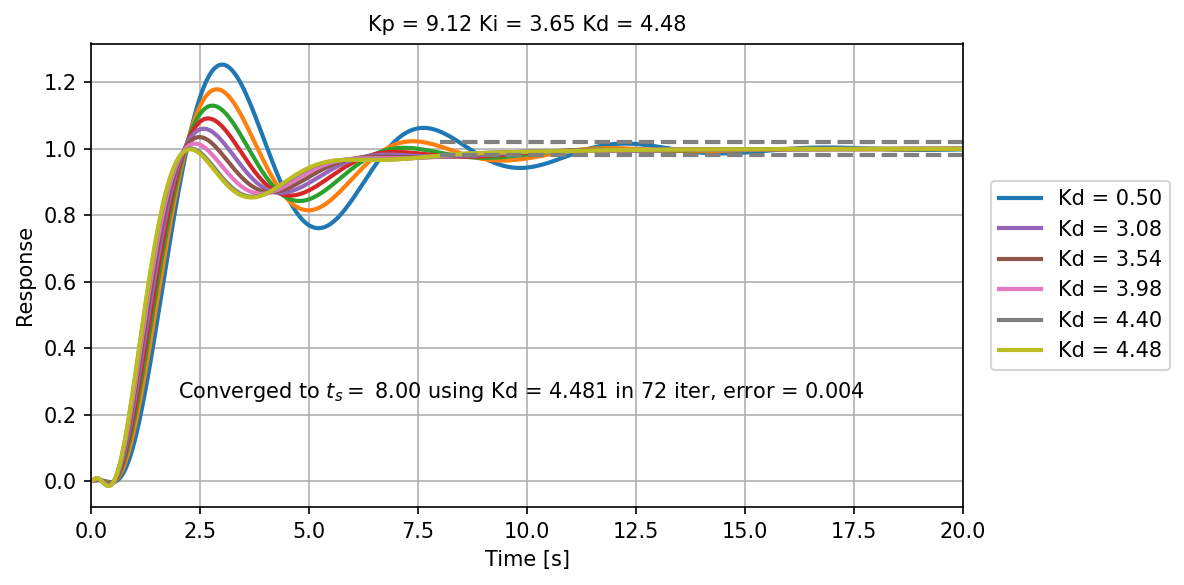

In [119]:
def find_pid_kd(G, Kp, Ki, Kd0=1, Tf=100, yss=1, ts_target=5, Nskip=10, err_target=0.02, Niter=250, Tol=0.05, ax=ax):
    '''
    Heuristic search for Kd to meet target settling time.
    Args:   
    yss = 1 # target steady state
    Kd0 = 1 # initial guess
    ts_target = 5 # target settling time
    Nskip = 5 # plot every Nskip iterations
    err_target = 0.02 # determination of settling time
    Niter = 100 # maximum iterations
    Tol = 0.05 # tolerance for settling time
  
    Returns:
        Kd - found derivative gain
        msgs - message about convergence    
    '''
    msgs = None
    Kd = Kd0

    def output_plot(ax, last_time, ts_target, t, y, Kd):
        print(rf"Kd = {Kd:.3f}, error = {abs(last_time - ts_target):.3f}")
        ax.plot(t, y, label=f"Kd = {Kd:.2f}")
        short_legend(ax)

    for kk in range(Niter):
        Gc = cm.pid(Kp=Kp, Ki=Ki, Kd=Kd)
        Gcl = ct.feedback(Gc * G)
        tt = np.linspace(0, Tf, 2000)
        [y, t] = cmat.step(Gcl, tt)

        # find when converged to within err_target
        err = np.abs(y - yss)
        last_time = t[np.where(err > err_target)[0][-1]]

        # plot occasionally
        if kk==0 or kk%Nskip == 0:
            output_plot(ax, last_time, ts_target, t, y, Kd)
        if kk%(5*Nskip) == 0:
            clear_output(wait=True)

        if abs(last_time - ts_target) < Tol:    
            msgs = (f"Converged to $t_s=$ {ts_target:4.2f} using Kd = {Kd:4.3f} in {kk} iter, error = {abs(last_time - ts_target):.3f}")
            # plot last time if it wasn't plotted
            if kk%Nskip != 0:
                output_plot(ax, last_time, ts_target, t, y, Kd)
            break

        kstep = 0.25*Kd0/(1+0.25*np.sqrt(kk))
        if last_time < ts_target:
            Kd -= kstep
        else: #last_time > ts_target
            Kd += kstep

        if msgs is None:
            msgs = "Did not converge within max iterations"
            
    return Kd, msgs

Tf = 100
yss = 1
err_target=0.02
ts_target = 8

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
Kd, msgs = find_pid_kd(G, Kp, Ki, Kd0=0.5, Tf=Tf, yss=yss, ax=ax, ts_target=ts_target, err_target=err_target, Tol=0.006)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Response')
ax.set_title(f"Kp = {Kp:.2f} Ki = {Ki:.2f} Kd = {Kd:.2f}")
ax.set_xlim([0, Tf/5])
ax.axhline(yss + err_target, xmin=ts_target/(Tf/5), color='gray', ls='dashed')
ax.axhline(yss - err_target, xmin=ts_target/(Tf/5), color='gray', ls='dashed')
if msgs is not None:
    ax.text(2, yss/4.0,msgs)
plt.savefig("./figs/L10_Manual_PID5.pdf", dpi=600)
plt.show()


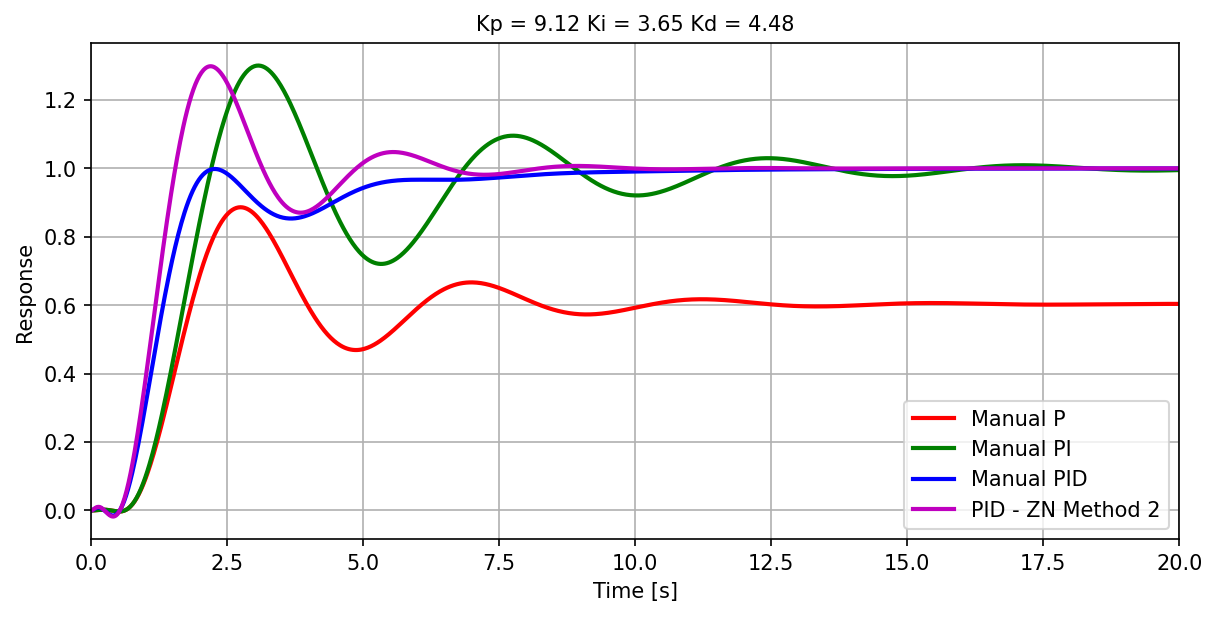

In [120]:
Gc = cm.pid(Kp=Kp, Ki=Ki, Kd=Kd)
fig, ax = plt.subplots(figsize=(8, 4), dpi=150, constrained_layout=True)
Gcl = ct.feedback(Gc * G, 1)
[y, t] = cmat.step(Gcl, max(tt)/5)

plt.plot(t_p, y_p, 'r', label='Manual P')
plt.plot(t_pi, y_pi, 'g', label='Manual PI')
plt.plot(t, y, 'b', label='Manual PID')
plt.plot(tpid, ypid, 'm', label='PID - ZN Method 2')
plt.xlim(0,max(tt)/5)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Response')
plt.title(f"Kp = {Kp:.2f} Ki = {Ki:.2f} Kd = {Kd:.2f}")
plt.savefig("./figs/L10_Manual_PID6.pdf", dpi=600)
plt.show()

In [121]:
import ipywidgets as widgets
from ipywidgets import interact

class PIDSimulator:
    def __init__(self, G, Tf=20, Tmax=20, N=2000):
        self.G = G
        self.Tf = Tf
        self.Tmax = Tmax
        self.t = np.linspace(0, Tf, N)

        # stored responses
        self.reset()

    def reset(self):
        self.y_p   = np.zeros_like(self.t)
        self.y_pi  = np.zeros_like(self.t)
        self.y_pd  = np.zeros_like(self.t)
        self.y_pid = np.zeros_like(self.t)

    def simulate(self, Kp, Ki, Kd):
        Gc = cm.pid(Kp=Kp, Ki=Ki, Kd=Kd)
        Gcl = ct.feedback(Gc * self.G, 1)
        y, _ = cmat.step(Gcl, T=self.t)
        return y

    def run(self, Kp, Ki, Kd):
        # compute response
        y = self.simulate(Kp, Ki, Kd)

        # store based on controller type
        if Ki == 0 and Kd == 0:
            self.y_p = y
        elif Ki != 0 and Kd == 0:
            self.y_pi = y
        elif Ki == 0 and Kd != 0:
            self.y_pd = y
        else:
            self.y_pid = y

        # plot
        fig, ax = plt.subplots(figsize=(8, 5), dpi=150, constrained_layout=True)

        ax.axhline(y[-1], xmin=0.5, color='k', linestyle='--')
        ax.plot(self.t, self.y_p,   'r-', label='P')
        ax.plot(self.t, self.y_pi,  'g-', label='PI')
        ax.plot(self.t, self.y_pd,  'c-', label='PD')
        ax.plot(self.t, self.y_pid, 'm-', label='PID')

        ax.set_xlim(0, self.Tmax)
        ax.set_ylim(-0.2, 2)
        ax.set_xlabel('Time [s]')
        ax.set_ylabel('Response')

        ax.text(
            0.5, 1.75,
            fr'$K_p={Kp:.2f},\ K_i={Ki:.2f},\ K_d={Kd:.2f}$',
            fontsize=10
        )

        ax.legend()
        ax.set_title('PID Closed-Loop Response')
        plt.show()

    def widget(self):
        interact(
            self.run,
            Kp=widgets.FloatSlider(min=0, max=30, step=0.1, value=1.0),
            Ki=widgets.FloatSlider(min=0, max=20, step=0.1, value=0.0),
            Kd=widgets.FloatSlider(min=0, max=10, step=0.1, value=0.0),
        )

In [ ]:
Tf = 100
Tmax= 20
T_delay = 0.5
num,den = ct.pade(T_delay, 2)
G = ct.tf((0, 1), np.convolve((1,3),np.convolve((1,1),(1,2))))*ct.tf(num, den)

sim = PIDSimulator(G, Tf=Tf, Tmax=Tmax)
sim.widget()

interactive(children=(FloatSlider(value=1.0, description='Kp', max=30.0), FloatSlider(value=0.0, description='…